
KATEGORI        | JUMLAH GAMBAR
----------------------------------------
APPLES          | 2071 file
BANANA          | 2080 file
ORANGES         | 2157 file

Proses EDA Selesai. Grafik dan sampel telah ditampilkan.


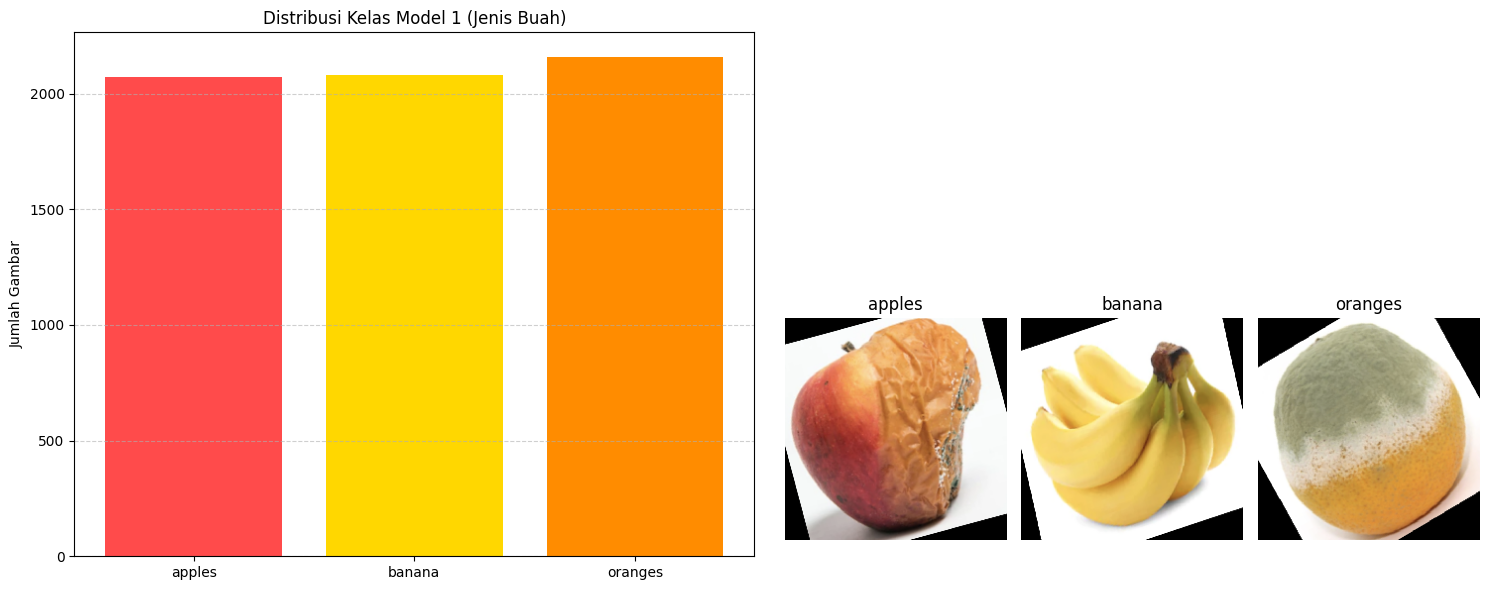

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

base_path = 'master_dataset/dataset_jenis_buah/train'

folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f)) and not f.startswith('.')]
folders.sort()

stats = {}
samples = {}

for category in folders:
    folder_path = os.path.join(base_path, category)
    images = [img for img in os.listdir(folder_path) if not img.startswith('.')]
    stats[category] = len(images)
    if len(images) > 0:
        samples[category] = os.path.join(folder_path, images[0])

print("\n" + "="*40)
print(f"{'KATEGORI':<15} | {'JUMLAH GAMBAR'}")
print("-"*40)
for cat, count in stats.items():
    print(f"{cat.upper():<15} | {count} file")
print("="*40 + "\n")

fig = plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.bar(stats.keys(), stats.values(), color=['#FF4B4B', '#FFD700', '#FF8C00'])
plt.title('Distribusi Kelas Model 1 (Jenis Buah)')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, (cat, path) in enumerate(samples.items()):
    if i >= 3: break
    img = tf.keras.utils.load_img(path, target_size=(224, 224))
    ax = fig.add_subplot(2, 6, i + 10)
    plt.imshow(img)
    plt.title(cat)
    plt.axis('off')

plt.tight_layout()
print("Proses EDA Selesai. Grafik dan sampel telah ditampilkan.")
plt.show()